In [1]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import os
import krippendorff

In [2]:
test_files = glob.glob('../Annotations_Tests/Test*/Test*_consolidation.csv')
main_files = glob.glob('../Annotation_Main/Main*/Main*_consolidation.csv')

print(test_files)
print(main_files)
print('No. of test files: ', len(test_files))
print('No. of main files: ', len(main_files))

all_files = test_files + main_files
print(all_files)
print('No. of main files: ', len(all_files))

['../Annotations_Tests/Test1/Test1_consolidation.csv', '../Annotations_Tests/Test3/Test3_consolidation.csv', '../Annotations_Tests/Test2/Test2_consolidation.csv']
['../Annotation_Main/Main4/Main4_consolidation.csv', '../Annotation_Main/Main3/Main3_consolidation.csv', '../Annotation_Main/Main2/Main2_consolidation.csv', '../Annotation_Main/Main5/Main5_consolidation.csv', '../Annotation_Main/Main1/Main1_consolidation.csv']
No. of test files:  3
No. of main files:  5
['../Annotations_Tests/Test1/Test1_consolidation.csv', '../Annotations_Tests/Test3/Test3_consolidation.csv', '../Annotations_Tests/Test2/Test2_consolidation.csv', '../Annotation_Main/Main4/Main4_consolidation.csv', '../Annotation_Main/Main3/Main3_consolidation.csv', '../Annotation_Main/Main2/Main2_consolidation.csv', '../Annotation_Main/Main5/Main5_consolidation.csv', '../Annotation_Main/Main1/Main1_consolidation.csv']
No. of main files:  8


In [3]:
mapping_3class = {
    'Positive': 'Positive',
    'M_Positive': 'Positive',    
    'Negative': 'Negative',
    'M_Negative': 'Negative',
    'P_Neutral': 'Neutral',
    'N_Neutral': 'Neutral',
    }

results = []


def compute_KA_ACC(df, tag_cols, mapping_3class, subset_name):
    #--6-class--#
    tag_to_code6 = {label: idx for idx, label in enumerate(pd.unique(df[tag_cols].values.ravel()))}
    for col in tag_cols:
        df[col + '_6class'] = df[col].map(tag_to_code6)
    data_6class = df[[col + '_6class' for col in tag_cols]].to_numpy().T
    alpha6 = krippendorff.alpha(reliability_data=data_6class, level_of_measurement='nominal')

    #---3-class---
    for col in tag_cols:
        df[col + '_3class'] = df[col].map(mapping_3class)
    tag_to_code3 = {label: idx for idx, label in enumerate(pd.unique(df[[col + "_3class" for col in tag_cols]].values.ravel()))}
    
    for col in tag_cols:
        df[col + '_3code'] = df[col + '_3class'].map(tag_to_code3)
    data_3class = df[[col + '_3code' for col in tag_cols]].to_numpy().T
    alpha3 = krippendorff.alpha(reliability_data=data_3class, level_of_measurement="nominal")

    #----Agreement---#
    def percent_agreement(rows):
        values = [val for val in rows if pd.notnull(val)]
        return int(len(set(values)) == 1)
    
    acc6 = df[tag_cols].apply(percent_agreement, axis=1).mean()
    acc3 = df[[col + '_3class' for col in tag_cols]].apply(percent_agreement, axis=1).mean()

    return {
        f'KA_6_{subset_name}': round(alpha6, 2),
        f'KA_3_{subset_name}': round(alpha3, 2),
        f'ACC_6_{subset_name}': round(acc6 * 100, 1),
        f'ACC_3_{subset_name}': round(acc3 * 100, 1)
    }
    


for file in all_files:
    df = pd.read_csv(file)
    pilot_name = os.path.splitext(os.path.basename(file))[0]
    base_name = pilot_name.split('_')[0]

    
    #Selecting columns with annotation tags (tag_tamara, tag_katja, tag_anze)
    tag_cols = [col for col in df.columns if col.startswith("tag_")]

    #Handle values with added Sarcasm note (Negative(S) -> Negative)
    for col in tag_cols:
        df[col] = df[col].astype("str").str.strip().str.replace(r"\(S\)", "", regex=True)
    
    #KA and ACC for full dataset
    metrics_full = compute_KA_ACC(df.copy(), tag_cols, mapping_3class, 'full')

    #KA and ACC for non-procedural speeches only (i.e. chair != True)
    df_non = df[df['chair'] != True]
    metrics_non = compute_KA_ACC(df_non.copy(), tag_cols, mapping_3class, 'nonproc')

    result_row = {"Phase": base_name}
    result_row.update(metrics_full)
    result_row.update(metrics_non)
    results.append(result_row)


summary = pd.DataFrame(results)
summary['sort_key'] = summary['Phase'].apply(lambda x: 0 if 'Test' in x else 1)
summary = summary.sort_values(by='sort_key').drop(columns='sort_key').reset_index(drop=True)
summary

,Phase,KA_6_full,KA_3_full,ACC_6_full,ACC_3_full,KA_6_nonproc,KA_3_nonproc,ACC_6_nonproc,ACC_3_nonproc
0,Test1,0.84,0.91,89.5,94.7,0.70,0.77,80.0,90.0
1,Test3,0.79,0.83,86.0,90.0,0.66,0.64,76.0,80.0
2,Test2,0.69,0.71,80.0,84.0,0.54,0.51,65.4,69.2
3,Main4,0.74,0.83,82.5,90.5,0.50,0.62,67.0,82.5
4,Main3,0.75,0.89,83.5,93.5,0.61,0.81,75.3,90.7
5,Main2,0.67,0.84,78.5,91.0,0.47,0.70,64.1,83.7
6,Main5,0.75,0.88,84.0,93.5,0.61,0.79,72.6,89.5
7,Main1,0.71,0.82,80.8,89.9,0.62,0.77,72.2,86.6


In [4]:
summary.to_csv('../Tables/KA_Tracking.csv', encoding='utf-8', index=False)


In [ ]:
df_ka = summary.melt(id_vars='Phase', value_vars=[col for col in summary.columns if col.startswith('KA')],
                     var_name='Metric', value_name='KA')
df_ka['Scale'] = df_ka['Metric'].apply(lambda x: '6-class' if '_6' in x else '3-class')
df_ka['Condition'] = df_ka['Metric'].apply(lambda x: 'Full' if 'full' in x else 'Non-procedural')

#Order_full = all columns, order = Main only
order_full = ['Test1', 'Test2', 'Test3', 'Main1', 'Main2', 'Main3', 'Main4', 'Main5']
order = ['Main1', 'Main2', 'Main3', 'Main4', 'Main5']

df_ka['Phase'] = pd.Categorical(df_ka['Phase'], categories=order_full, ordered=True)


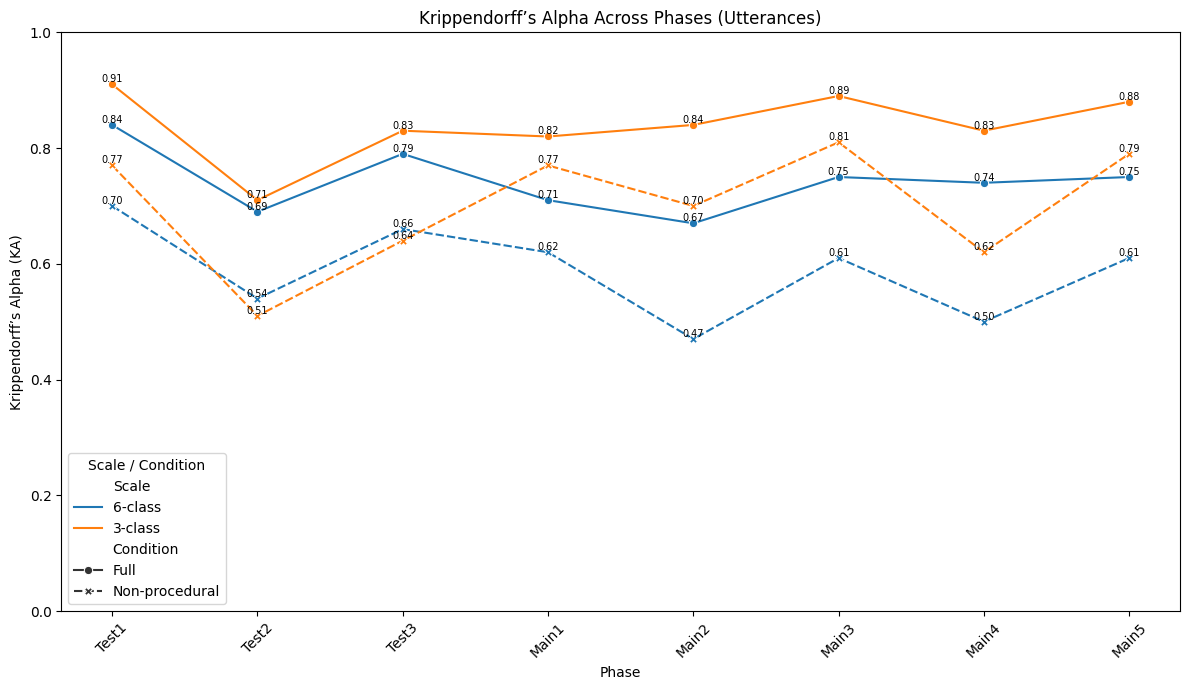

In [16]:
plt.figure(figsize=(12, 7))
lineplot = sns.lineplot(data=df_ka,
             x='Phase', y='KA',
             hue='Scale', style='Condition',
             markers=True, dashes=True)

plt.title("Krippendorff’s Alpha Across Phases (Utterances)")
plt.ylabel("Krippendorff’s Alpha (KA)")
plt.ylim(0, 1) 
plt.xticks(rotation=45)
plt.legend(title='Scale / Condition')

#Adding KA scores to the 
for line in lineplot.lines:
    for x_data, y_data in zip(line.get_xdata(), line.get_ydata()):
        plt.text(x_data, y_data, f'{y_data:.2f}', fontsize=7, ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../Figures/KA_Utternaces.png', dpi=300)
plt.show()